### Model dry run with t cell example

### Generate model inputs

In [1]:
import pickle
import numpy as np

import zipfile
from io import BytesIO
import tifffile
import pandas as pd
import seaborn as sns

import os

In [2]:
cvat_base_dir = '/gladstone/engelhardt/lab/adamw/MarsonImagingPipeline/data/ground_truth_tracking_annotations/cvat_annotations/TCR-T/'
crop = 'B4_t50t100y200y350x750x900'
well_id = crop.split("_")[0]

cvat_tracks = tifffile.imread(os.path.join(cvat_base_dir, well_id, crop, 'ALL_tracks.tiff'))
cell_type_dict = pickle.load(open(os.path.join(cvat_base_dir, well_id, crop, f'full_cell_type_dict.pkl'), "rb"))

In [3]:
def filter_tracks_by_type(track_type, tracks, type_dict):
    """Filter tracks to only contain tracks of the desired cell type

    Args:
        track_type (str): Type of track to filter for, matching a key in type_dict
        tracks (np.ndarray): Tracked cell mask [T, Y, X]
        type_dict (dict): Dictionary mapping cell id to cell type
        min_t (int, optional): minimum number of time frames that a cell 
                               needs to appear for to avoid being filtered. 
                               Defaults to 0.
    """

    # Filter by cell type
    valid_ids = [cell_id for cell_id, cell_type in type_dict.items() if cell_type == track_type]
    filtered_tracks = tracks.copy()
    filtered_tracks[~np.isin(filtered_tracks, valid_ids)] = 0
    
    return filtered_tracks

In [4]:
type_tracks_per_well = {}
for cell_type in ['cancer', 't_cell']:
    type_tracks_per_well[cell_type] = filter_tracks_by_type(cell_type, cvat_tracks, cell_type_dict)

In [5]:
t_cell_tracks = type_tracks_per_well['t_cell']
t_cell_tracks.shape

(50, 150, 150)

In [6]:
data = {}

T = t_cell_tracks.shape[0]
all_cell_ids = np.unique(t_cell_tracks[t_cell_tracks > 0])
all_cell_ids.sort()
num_cells = len(all_cell_ids)
id_to_col = {int(cid): i for i, cid in enumerate(all_cell_ids)}

print(f"T={T}, num_cells={num_cells}")

# Initialize all masks
active_mask = np.zeros((T, num_cells), dtype=bool)
is_division_mask = np.zeros((T, num_cells), dtype=bool)
is_new_root_mask = np.zeros((T, num_cells), dtype=bool)
parent_indices = np.zeros((T, num_cells), dtype=np.int32)

# Make active_mask from t_cell_tracks
for t in range(T):
    t_cell_frame = t_cell_tracks[t]
    frame_ids = np.unique(t_cell_frame[t_cell_frame > 0])
    for cid in frame_ids:
        active_mask[t, id_to_col[int(cid)]] = True

# 4. Build is_new_root_mask, parent_indices (keep is_division_mask as all False)
for cid, col in id_to_col.items():
    active_frames = np.where(active_mask[:, col])[0]
    if len(active_frames) == 0:
        print(f"Warning: Cell ID {cid} (col {col}) is never active in active_mask. Skipping.")
        continue

    first_frame = active_frames[0]

    # This cell is a root (appeared spontaneously or is the initial cell)
    is_new_root_mask[first_frame, col] = True
    parent_indices[first_frame, col] = col  # self

    # For all subsequent active frames, parent = self (cell continues)
    for t in active_frames[1:]:
        parent_indices[t, col] = col

data["parent_indices"] = parent_indices
data['active_mask'] = active_mask
data["is_division_mask"] = is_division_mask
data["is_new_root_mask"] = is_new_root_mask

# 5. Summary
print(f"active_mask shape:       {active_mask.shape}")
print(f"parent_indices shape:    {parent_indices.shape}")
print(f"is_division_mask shape:  {is_division_mask.shape}")
print(f"is_new_root_mask shape:  {is_new_root_mask.shape}")
print(f"Division events (daughters): {is_division_mask.sum()}")
print(f"Root cells:                  {is_new_root_mask.sum()}")

T=50, num_cells=110
active_mask shape:       (50, 110)
parent_indices shape:    (50, 110)
is_division_mask shape:  (50, 110)
is_new_root_mask shape:  (50, 110)
Division events (daughters): 0
Root cells:                  110


In [7]:
import matplotlib.pyplot as plt

def visualize_full_lineage(data):
    """
    Visualizes the tree lineage vertically.
    Y-axis: Time (starts at 0 at the top, goes down).
    X-axis: Unique Cell ID.
    """
    parent_indices = np.array(data['parent_indices'])
    active_mask = np.array(data['active_mask'])
    is_new_root = np.array(data['is_new_root_mask'])
    is_division = np.array(data['is_division_mask'])
    
    T, MaxCells = active_mask.shape
    
    plt.figure(figsize=(12, 10))
    
    # 1. Draw Cell Tracks (Vertical Lines)
    # We iterate by ID to draw contiguous vertical lines for each unique cell
    # Limit visualization to first 64 cells
    max_cells_to_show = MaxCells
    
    for cell_id in range(min(MaxCells, max_cells_to_show)):
        # Find time points where this cell is active
        active_times = np.where(active_mask[:, cell_id])[0]
        
        if len(active_times) > 0:
            # Draw the life of the cell vertically
            # X = Cell ID (Constant), Y = Time (Variable)
            plt.plot([cell_id] * len(active_times), active_times, 
                     marker='o', markersize=4, linewidth=3, alpha=0.7, 
                     color='skyblue', label='Cell Life' if cell_id == 0 else "")
            
            # Label the start of the track
            t_start = active_times[0]
            
            # 2. Draw Connections to Parents (Upwards)
            if t_start > 0:
                parent_id = parent_indices[t_start, cell_id]
                
                # Only draw parent connections if parent is also in the visible range
                if parent_id < max_cells_to_show:
                    # Check if this is a "New Root" (Spontaneous) or a Child
                    if is_new_root[t_start, cell_id]:
                        # Star marker for spontaneous appearance
                        plt.plot(cell_id, t_start, marker='*', color='green', markersize=12, label='New Root' if cell_id==0 else "")
                    else:
                        # Draw connection line from Parent(t-1) to Child(t)
                        # Parent is at (parent_id, t_start - 1)
                        # Child is at (cell_id, t_start)
                        plt.plot([parent_id, cell_id], [t_start - 1, t_start], 
                                 color='gray', linestyle='--', linewidth=1, alpha=0.5)
                        
                        # If this was a division, mark the birth point
                        if is_division[t_start, cell_id]:
                             plt.plot(cell_id, t_start, marker='^', color='red', markersize=8, label='Division Child' if cell_id==0 else "")

    plt.ylabel("Time Step (t=0 at Top)")
    plt.xlabel("Unique Cell ID (Column Index)")
    plt.title("Lineage Tree Visualization (Vertical Flow)")
    
    # Invert Y axis so time goes down
    plt.gca().invert_yaxis()
    
    # Grid and Ticks
    plt.grid(True, alpha=0.3)
    # Crop x-axis to show only first 64 cells
    plt.xlim(-0.5, max_cells_to_show - 0.5)
    plt.xticks(np.arange(0, max_cells_to_show, 1), rotation=90)
    plt.yticks(np.arange(0, T, 1))
    #plt.axis('off')
    
    # Create a custom legend manually to avoid duplicate labels
    from matplotlib.lines import Line2D
    custom_lines = [
        Line2D([0], [0], color='skyblue', lw=3, marker='o', label='Active Cell (Vertical)'),
        Line2D([0], [0], color='gray', lw=1, linestyle='--', label='Parent Link'),
        Line2D([0], [0], color='red', lw=0, marker='^', label='Born from Division'),
        Line2D([0], [0], color='green', lw=0, marker='*', label='Spontaneous Root')
    ]
    plt.legend(handles=custom_lines, loc='upper right')
    
    plt.tight_layout()
    plt.show()

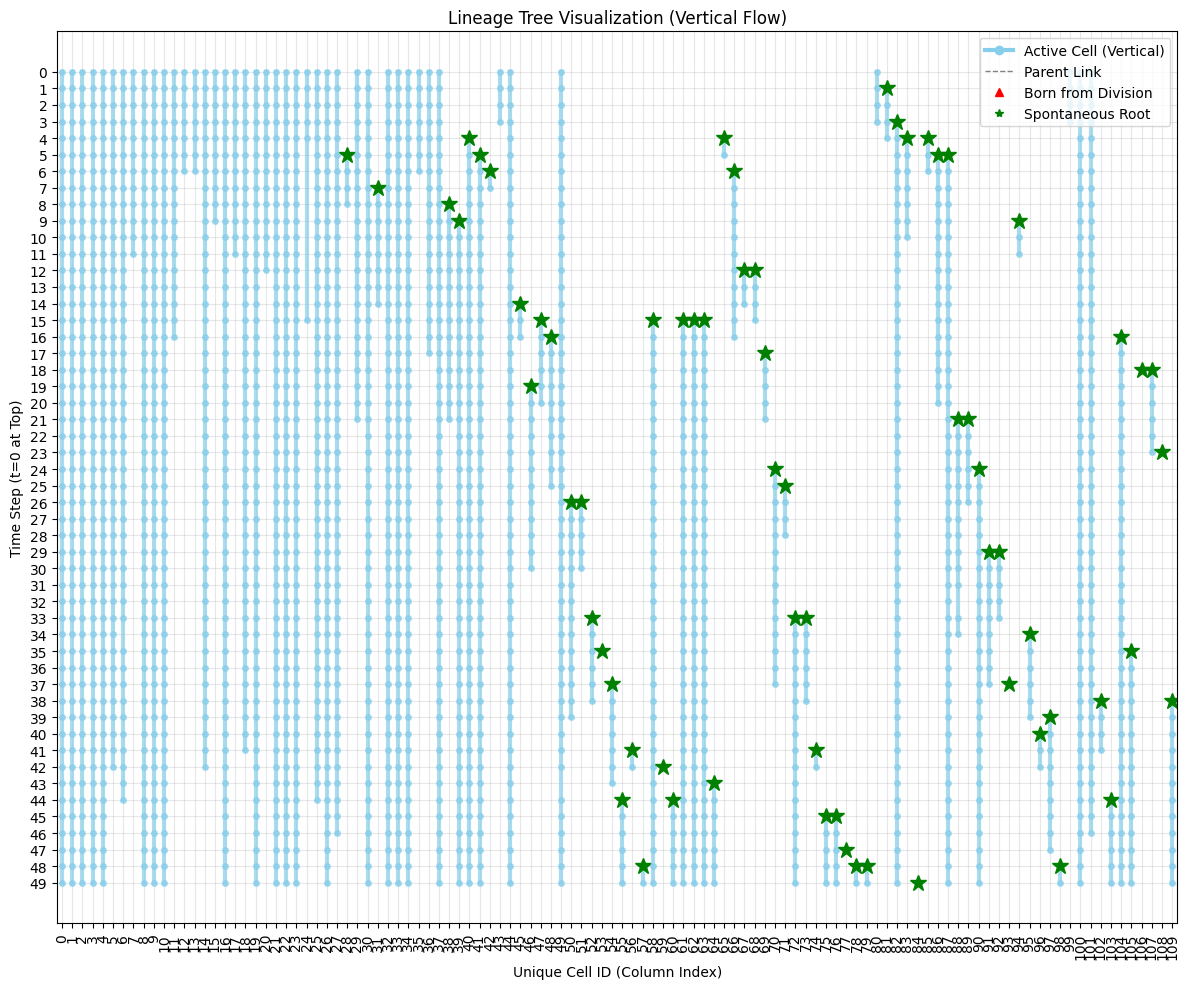

In [8]:
visualize_full_lineage(data)

In [9]:
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [10]:
# visualize emissions
emissions = np.load(f"/gladstone/engelhardt/lab/adamw/treeHMM/notebooks/data/example_gt_crop/{crop}/t_cell_emissions_array.npy")
emissions.shape

(50, 110, 3)

Filter both the `data` and `emissions` objects based on the number of consecutive frames each cell appears in.

In [11]:

def filter_tracks_by_time(data, emissions, min_t=10):
    """
    Filters 'data' and 'emissions' objects to retain only cells present 
    in at least min_t unique time frames.
    
    Args:
        data (dict): Dictionary containing tracking arrays (active_mask, parent_indices, etc.)
                     Each array has shape (T, num_cells).
        emissions (np.ndarray): Array of shape (T, num_cells, num_features).
        min_t (int): Minimum number of active time frames required to keep a cell.
        
    Returns:
        tuple: (filtered_data, filtered_emissions)
    """
    
    # 1. Calculate duration for each cell (sum of active frames across time)
    durations = np.sum(data['active_mask'], axis=0)
    
    # 2. Identify indices of cells to keep
    keep_indices = np.where(durations >= min_t)[0]
    
    if len(keep_indices) == 0:
        print(f"Warning: No cells found with duration >= {min_t} frames.")
        T, _, D = emissions.shape
        empty_data = {k: np.zeros((T, 0), dtype=v.dtype) if isinstance(v, np.ndarray) else v 
                      for k, v in data.items()}
        return empty_data, np.zeros((T, 0, D))
    
    # 3. Subset emissions array [T, num_cells, num_features]
    filtered_emissions = emissions[:, keep_indices, :]
    
    # 4. Subset all tracking masks in the data dictionary [T, num_cells]
    filtered_data = {}
    for key, val in data.items():
        if isinstance(val, np.ndarray) and val.ndim >= 2:
            filtered_data[key] = val[:, keep_indices]
        else:
            filtered_data[key] = val
            
    # 5. Update parent_indices to reflect new column mapping
    # Create mapping from old column index to new column index
    old_to_new = {old_idx: new_idx for new_idx, old_idx in enumerate(keep_indices)}
    
    # Create a lookup table for fast vectorized mapping
    max_old_idx = data['parent_indices'].max()
    lookup = np.full(max_old_idx + 1, -1, dtype=np.int32)
    for old_idx, new_idx in old_to_new.items():
        lookup[old_idx] = new_idx
        
    # Map parent indices only for active time points
    curr_parents = filtered_data['parent_indices']
    curr_active = filtered_data['active_mask']
    new_parents = np.copy(curr_parents)
    
    # Apply lookup only where cells are active
    rows, cols = np.where(curr_active)
    new_parents[rows, cols] = lookup[curr_parents[rows, cols]]
    
    # 6. Handle "Orphans"
    # If a cell is kept but its parent was discarded, mark the cell as a new root
    orphans = (new_parents == -1) & curr_active
    if np.any(orphans):
        filtered_data['is_new_root_mask'][orphans] = True
        # Set parent to self for these newly orphaned roots
        o_rows, o_cols = np.where(orphans)
        new_parents[o_rows, o_cols] = o_cols
        
    filtered_data['parent_indices'] = new_parents
    
    print(f"Filtered {data['active_mask'].shape[1]} cells down to {len(keep_indices)} cells.")
    return filtered_data, filtered_emissions

# Example Usage:
data, emissions = filter_tracks_by_time(data, emissions, min_t=0)
emissions.shape

Filtered 110 cells down to 110 cells.


(50, 110, 3)

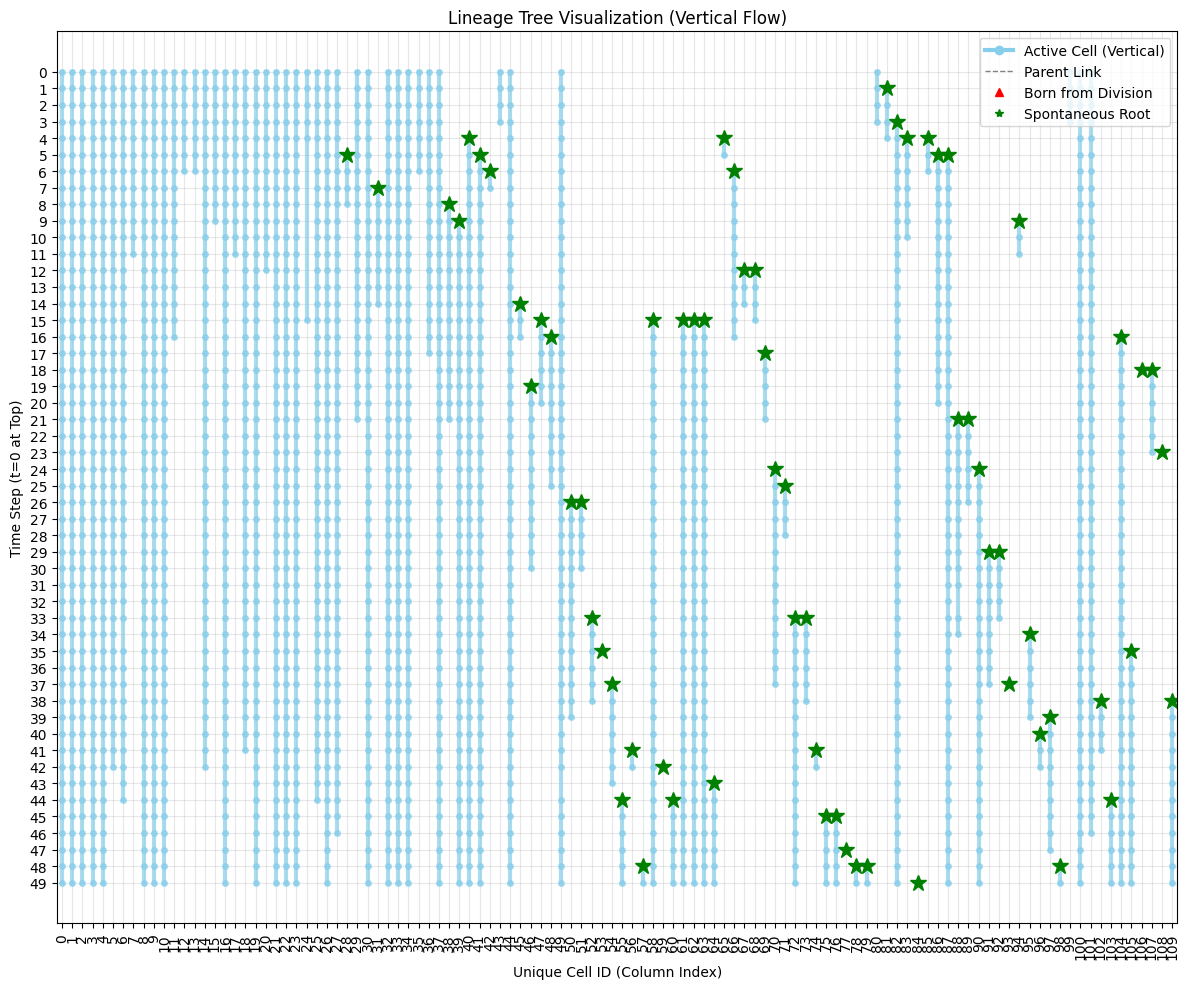

In [12]:
visualize_full_lineage(data)

In [13]:
reshaped_emissions = emissions.reshape(-1, emissions.shape[-1])  # [T*num_cells, num_features]
reshaped_emissions.shape

(5500, 3)

In [14]:
for i in range(5):
    kmeans = KMeans(n_clusters=i+2, random_state=0).fit(reshaped_emissions)
    score = silhouette_score(reshaped_emissions, kmeans.labels_)
    print(f"Silhouette Score for {i+2} clusters: {score:.4f}")

Silhouette Score for 2 clusters: 0.7983
Silhouette Score for 3 clusters: 0.7050
Silhouette Score for 4 clusters: 0.7083
Silhouette Score for 5 clusters: 0.7145
Silhouette Score for 6 clusters: 0.7198


In [15]:
kmeans = KMeans(n_clusters=4, random_state=0).fit(reshaped_emissions)

In [16]:
kmeans.labels_

array([0, 0, 0, ..., 0, 0, 2], dtype=int32)

In [17]:
pca = PCA(n_components=2)
pca_embeddings = pca.fit_transform(reshaped_emissions)
print(pca.explained_variance_ratio_)
print(np.sum(pca.explained_variance_ratio_))

[0.84799972 0.11243416]
0.9604338811418808


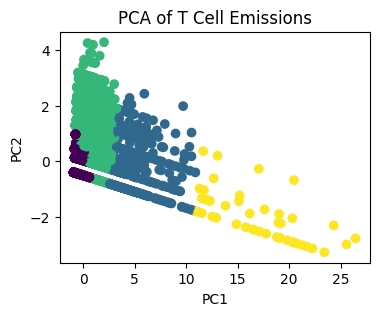

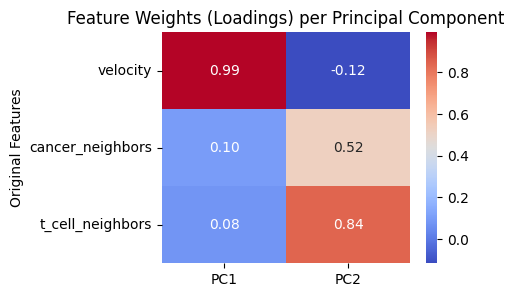

In [18]:
colors = kmeans.labels_

plt.figure(figsize=(4, 3))
plt.scatter(pca_embeddings[:, 0], pca_embeddings[:, 1], c=colors, cmap='viridis')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title("PCA of T Cell Emissions")
plt.show()

component_weights = pd.DataFrame(
    pca.components_.T,  # Transpose to get features as rows
    columns=['PC1', 'PC2'],
    index=['velocity', 'cancer_neighbors', 't_cell_neighbors']
)

plt.figure(figsize=(4, 3))
sns.heatmap(component_weights, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Feature Weights (Loadings) per Principal Component')
plt.ylabel('Original Features')
plt.show()


### Initialize and run model

In [19]:
import sys
import os
import importlib

os.chdir("/gladstone/engelhardt/lab/adamw/treeHMM")

import jax
import jax.numpy as jnp
import jax.random as jr
from jax.scipy.stats import multivariate_normal

from utils import generate_tree_hmm_data
from utils import visualize_lineage

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from dynamax.hidden_markov_model import LinearAutoregressiveHMM
from models.tarhmm import tARHMM
from dynamax.utils.plotting import gradient_cmap
from dynamax.utils.utils import random_rotation
#from dynamax.hidden_markov_model.models.tarhmm import tree_hmm_backward_filter
from typing import Callable, Optional
from dynamax.types import IntScalar, Float, Array

# module import version sanity check
hasattr(jax.interpreters.xla, 'pytype_aval_mappings')


An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


True

In [20]:
num_states = 3
emission_dim = 3
num_lags = 1

In [21]:
emissions.shape, data['is_division_mask'].shape, data['is_new_root_mask'].shape, data['parent_indices'].shape, data['active_mask'].shape

((50, 110, 3), (50, 110), (50, 110), (50, 110), (50, 110))

In [22]:
arhmm = tARHMM(num_states, emission_dim, num_lags=num_lags)
params, props = arhmm.initialize(key=jr.PRNGKey(1), method="kmeans", emissions=emissions)
inputs = arhmm.compute_inputs(
    jnp.array(emissions),
    jnp.array(data['parent_indices']),
    jnp.array(data['is_division_mask']),
    jnp.array(data['is_new_root_mask']),
    jnp.array(data['active_mask']),
)

In [23]:
batched_emissions = jnp.stack([emissions,emissions])
batched_inputs = jnp.stack([inputs,inputs])
batched_parent_indices = jnp.stack([data['parent_indices'], data['parent_indices']])
batched_is_division_mask = jnp.stack([data['is_division_mask'], data['is_division_mask']])
batched_active_mask = jnp.stack([data['active_mask'], data['active_mask']])
batched_is_new_root_mask = jnp.stack([data['is_new_root_mask'], data['is_new_root_mask']])


In [24]:
batched_emissions = emissions
batched_inputs = inputs
batched_parent_indices = data['parent_indices']
batched_is_division_mask = data['is_division_mask']
batched_active_mask = data['active_mask']
batched_is_new_root_mask = data['is_new_root_mask']

In [25]:
fitted_params, lps = arhmm.fit_em(params, props, batched_emissions, inputs=batched_inputs,
    parent_indices=batched_parent_indices,
    is_division_mask=batched_is_division_mask,
    active_mask=batched_active_mask,
    is_new_root_mask=batched_is_new_root_mask)

<div><progress max="50" value="50"></progress> 100.00% [50/50 00:01&lt;00:00]</div>

In [26]:
fitted_params

ParamsLinearTreeARHMM(initial=ParamsStandardHMMInitialState(probs=Array([0.69278944, 0.00092427, 0.3062863 ], dtype=float32)), transitions=ParamsStandardHMMTransitions(transition_matrix=Array([[0.09794349, 0.19419625, 0.70786023],
       [0.12255464, 0.3286298 , 0.5488156 ],
       [0.02068678, 0.06877116, 0.910542  ]], dtype=float32)), division_transitions=ParamsStandardHMMTransitions(transition_matrix=Array([[0.3333332, 0.3333332, 0.3333332],
       [0.3333332, 0.3333332, 0.3333332],
       [0.3333332, 0.3333332, 0.3333332]], dtype=float32)), emissions=ParamsLinearRegressionHMMEmissions(weights=Array([[[ 1.04088731e-01,  5.41052878e-01,  2.04817891e-01],
        [-1.68414824e-02,  2.99286246e-01, -1.01004176e-01],
        [-3.13690454e-02, -1.57701254e-01,  6.01691008e-01]],

       [[ 4.90634948e-01, -1.44184077e+00, -1.34259760e+00],
        [-2.96258703e-02,  4.25584167e-01,  1.07141770e-01],
        [-8.39662924e-03,  1.47275394e-02,  6.25943840e-01]],

       [[ 5.35506904e-01, 

In [27]:
from models.tarhmm import tree_hmm_two_filter_smoother

In [28]:
# Compute the posterior distribution of the latent states
input_fwd = arhmm._inference_args(params, emissions, inputs, data['parent_indices'], data['is_division_mask'], data['active_mask'],data['is_new_root_mask'])

posterior = tree_hmm_two_filter_smoother(*input_fwd)

In [29]:
posterior

TreeHMMPosterior(marginal_loglik=Array(-13156.699, dtype=float32), filtered_probs=Array([[[3.6674310e-06, 0.0000000e+00, 9.9999636e-01],
        [3.6674310e-06, 0.0000000e+00, 9.9999636e-01],
        [4.0256095e-06, 0.0000000e+00, 9.9999601e-01],
        ...,
        [0.0000000e+00, 0.0000000e+00, 0.0000000e+00],
        [0.0000000e+00, 0.0000000e+00, 0.0000000e+00],
        [0.0000000e+00, 0.0000000e+00, 0.0000000e+00]],

       [[8.1865679e-08, 0.0000000e+00, 9.9999994e-01],
        [1.6020656e-05, 0.0000000e+00, 9.9998397e-01],
        [2.7771210e-07, 0.0000000e+00, 9.9999970e-01],
        ...,
        [0.0000000e+00, 0.0000000e+00, 0.0000000e+00],
        [0.0000000e+00, 0.0000000e+00, 0.0000000e+00],
        [0.0000000e+00, 0.0000000e+00, 0.0000000e+00]],

       [[9.5493469e-08, 0.0000000e+00, 9.9999994e-01],
        [6.2248737e-06, 0.0000000e+00, 9.9999380e-01],
        [8.2719794e-08, 0.0000000e+00, 9.9999994e-01],
        ...,
        [0.0000000e+00, 0.0000000e+00, 0.0000000e+

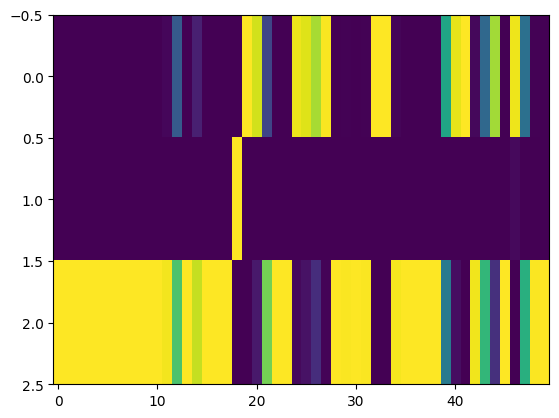

In [30]:
# T x C x features

plt.imshow(posterior.smoothed_probs[:,10,:].T, aspect="auto", interpolation="none", vmin=0, vmax=1)
#plt.xlim(4,15)

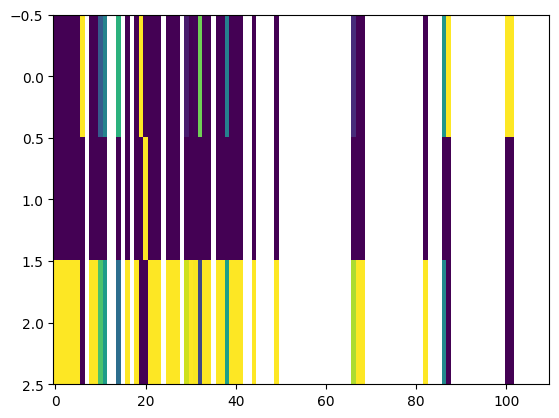

In [31]:
plt.imshow(posterior.smoothed_probs[12,:,:].T, aspect="auto", interpolation="none", vmin=0, vmax=1)
#plt.xlim(4,15)

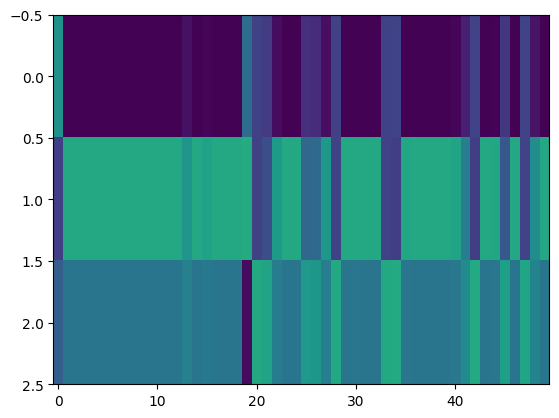

In [32]:
plt.imshow(posterior.predicted_probs[:,10,:].T, aspect="auto", interpolation="none", vmin=0, vmax=1)
#plt.xlim(4,15)

In [33]:
posterior.smoothed_probs.shape

(50, 110, 3)

In [34]:
state_assignments = jnp.argmax(posterior.smoothed_probs, axis=-1)
state_assignments.shape

(50, 110)

In [35]:
max_probs = jnp.max(posterior.smoothed_probs, axis=-1)
max_probs.shape

(50, 110)

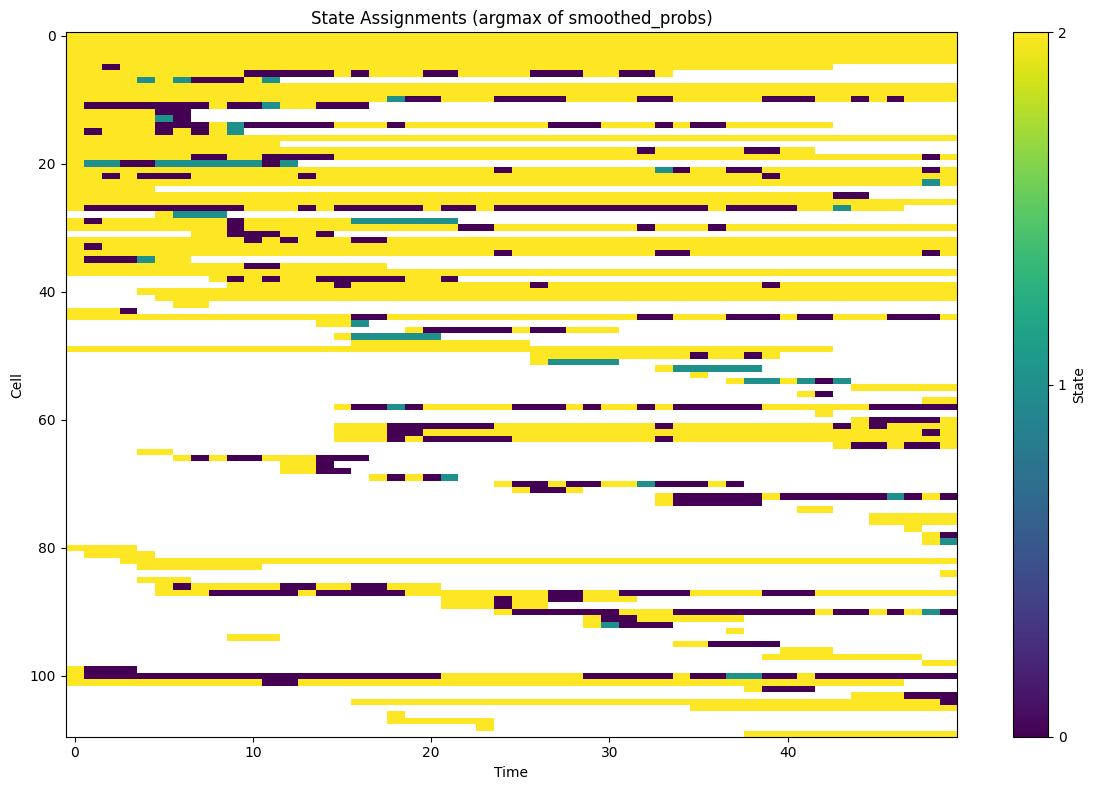

In [36]:
masked_state_assignments = jnp.where(jnp.isnan(max_probs.T), jnp.nan, state_assignments.T)

fig, ax = plt.subplots(figsize=(12, 8))
im = ax.imshow(masked_state_assignments, aspect="auto", interpolation="none", cmap="viridis", origin="upper")
ax.set_xlabel("Time")
ax.set_ylabel("Cell")
ax.set_title("State Assignments (argmax of smoothed_probs)")
cbar = plt.colorbar(im, ax=ax, ticks=range(num_states))
cbar.set_label("State")
plt.tight_layout()
plt.show()

In [37]:
masked_state_assignments.shape, emissions.shape

((110, 50), (50, 110, 3))

TODO: use `masked_state_assignments` and `emissions` to look at the distribution of each feature across all learned HMM states

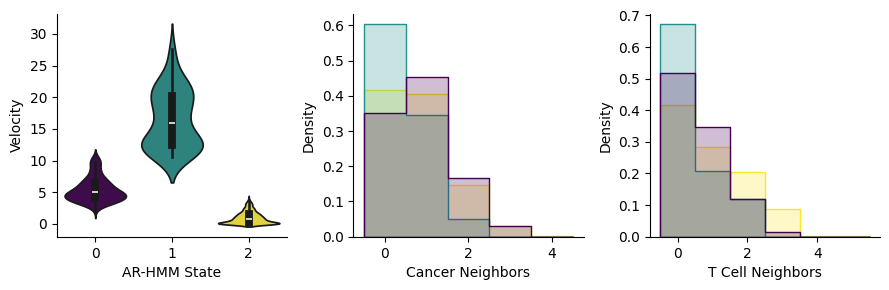

In [38]:

# 1. Align and flatten the data
# masked_state_assignments is (cell=58, time=50) -> transpose to (50, 58) to match emissions (50, 58, 3)
states_flat = np.array(masked_state_assignments.T).flatten()
# emissions is (time=50, cell=58, feature=3) -> reshape to (50*58, 3)
emissions_flat = np.array(emissions.reshape(-1, 3))

# 2. Create a DataFrame for plotting
feature_names = ['velocity', 'cancer_neighbors', 't_cell_neighbors']
plot_type = ['violin', 'hist', 'hist']
df = pd.DataFrame(emissions_flat, columns=feature_names)
df['state'] = states_flat

# 3. Filter out masked values (NaN)
df_clean = df.dropna(subset=['state']).copy()
df_clean['state'] = df_clean['state'].astype(int)

# 4. Generate Violin Plots
fig, axes = plt.subplots(1, 3, figsize=(9, 3), tight_layout=True)

for i, feature in enumerate(feature_names):
    if plot_type[i] == 'violin':
        sns.violinplot(
            data=df_clean, 
            x='state', 
            y=feature, 
            hue='state', 
            ax=axes[i], 
            palette='viridis', 
            legend=False
        )
        axes[i].set_ylabel(f'{feature.replace("_", " ").title()}')
        axes[i].set_xlabel('AR-HMM State')
    elif plot_type[i] == 'hist':
        sns.histplot(
            data=df_clean, 
            x=feature, 
            hue='state', 
            ax=axes[i], 
            palette='viridis',
            common_norm=False,
            stat='density',
            element='step',
            # multiple='fill',
            discrete=True,
            legend=False
        )
        axes[i].set_xlabel(f'{feature.replace("_", " ").title()}')
    sns.despine(ax=axes[i])

plt.show()


In [39]:
out_dir = os.path.join('/gladstone/engelhardt/lab/adamw/treeHMM/notebooks/data/example_gt_crop', crop)
os.makedirs(out_dir, exist_ok=True)
np.save(os.path.join(out_dir, 't_cell_state_assignments.npy'), state_assignments)